In [13]:
def get_experiment_duration(log_file_path):
    """
    Parse a PsychoPy log file and calculate experiment duration.
    
    The experiment starts when conditions are imported (around line 196 in the example).
    The experiment ends when text_14 appears (the "done!" message).
    
    Parameters:
    -----------
    log_file_path : str
        Path to the .log file
    
    Returns:
    --------
    dict
        Dictionary with keys:
        - 'start_time': float, timestamp when experiment began
        - 'end_time': float, timestamp when experiment ended
        - 'duration_formatted': str, duration in M:SS format
        - 'duration_seconds': float, duration in seconds
        - 'stimulus_file': str, name of the CSV file used for main trials
    """
    with open(log_file_path, 'r') as f:
        lines = f.readlines()
    
    start_time = None
    end_time = None
    stimulus_file = None
    
    # Find start and stimulus file: when conditions are imported for the main trial loop
    for i, line in enumerate(lines):
        if 'Imported' in line and '.csv' in line:
            # Extract timestamp from first column
            start_time = float(line.split('\t')[0])
            # Extract filename from the log line
            # Format is typically: "196.9220 	EXP 	Imported mocs_stims_fixed.csv as conditions, 648 conditions, 6 params"
            parts = line.split('\t')
            if len(parts) >= 3:
                log_msg = parts[2]
                # Extract filename between "Imported " and " as"
                if 'Imported' in log_msg and ' as' in log_msg:
                    start_idx = log_msg.find('Imported ') + len('Imported ')
                    end_idx = log_msg.find(' as')
                    stimulus_file = log_msg[start_idx:end_idx]
    
    # Find end: when text_14 appears (the done message)
    for i, line in enumerate(lines):
        if 'text_14' in line and 'autoDraw = True' in line:
            end_time = float(line.split('\t')[0])
            # Keep searching in case there's a later occurrence
    
    if start_time is None or end_time is None:
        return {
            'error': 'Could not find start or end markers in log file'
        }
    
    # Calculate duration
    duration_seconds = end_time - start_time
    
    # Convert to M:SS format
    minutes = int(duration_seconds) // 60
    seconds = int(duration_seconds) % 60
    duration_formatted = f"{minutes}:{seconds:02d}"
    
    return {
        'start_time': start_time,
        'end_time': end_time,
        'duration_seconds': duration_seconds,
        'duration_formatted': duration_formatted,
        'stimulus_file': stimulus_file
    }


# Test with the example log file
log_path = '/Users/bwinsto2/Documents/Documents - BV-PCR-VPJVMF3/Github/tilt/tilt_mocs/data/sub-21049988/ses-0/sub-21049988_ses-0_exp-tiltmocs_2025-12-03_13h26.13.795.log'
result = get_experiment_duration(log_path)

print("Experiment Duration Report")
print("=" * 40)
print(f"Stimulus file: {result['stimulus_file']}")
print(f"Start time:   {result['start_time']:.2f}s")
print(f"End time:     {result['end_time']:.2f}s")
print(f"Duration:     {result['duration_formatted']} ({result['duration_seconds']:.1f}s)")


Experiment Duration Report
Stimulus file: mocs_stims_fixed.csv
Start time:   196.92s
End time:     1267.08s
Duration:     17:50 (1070.2s)


Successfully parsed 12 subjects

Duration statistics by stimulus file:
                                         count    mean    std     min     25%  \
stimulus_file                                                                   
mocs_stims_fixed.csv                       9.0  1174.2  177.1   966.6  1070.2   
mocs_stims_fixed_whole_distribution.csv    3.0  1177.7   35.6  1140.0  1161.2   

                                            50%     75%     max  
stimulus_file                                                    
mocs_stims_fixed.csv                     1107.8  1262.2  1543.3  
mocs_stims_fixed_whole_distribution.csv  1182.4  1196.6  1210.8  

Detailed results:
     subject  duration_seconds duration_formatted                           stimulus_file
sub-21049992         1262.2461              21:02                    mocs_stims_fixed.csv
sub-21049993         1324.3605              22:04                    mocs_stims_fixed.csv
sub-21049994         1107.7536              18:27  

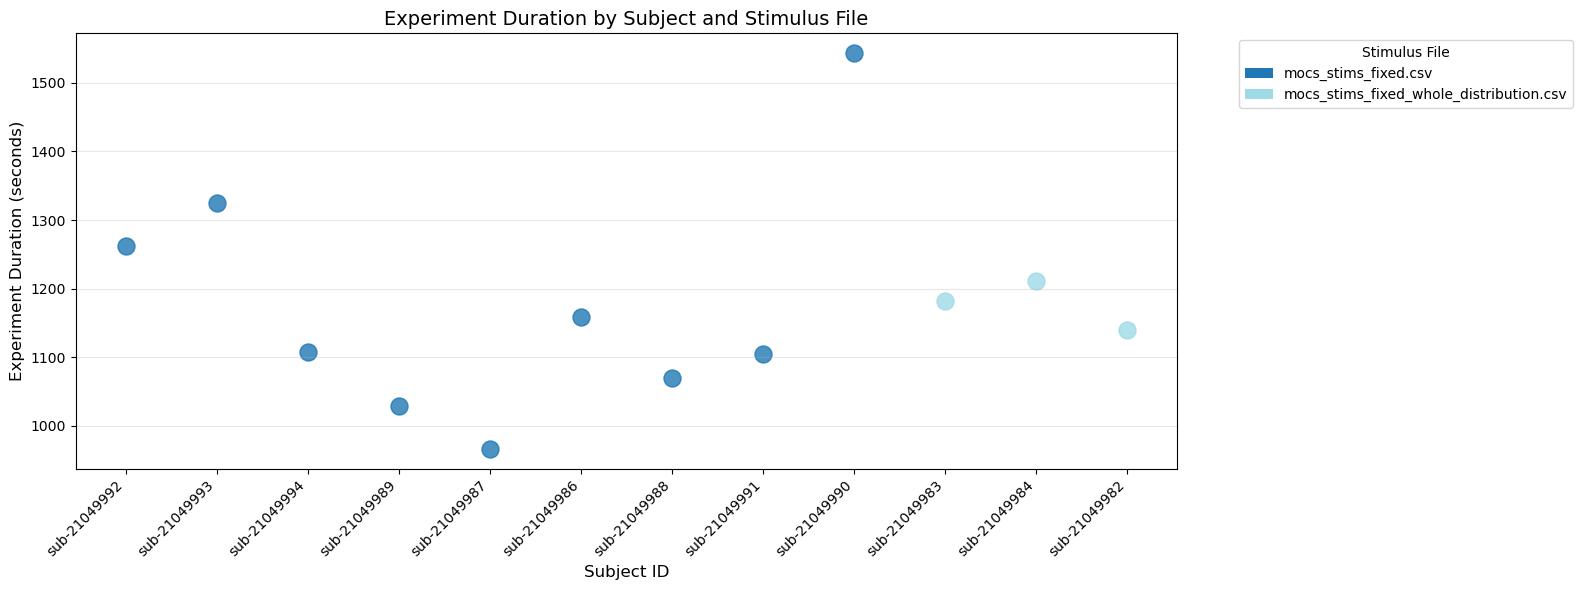

In [12]:
# get subs in data folder, but only the ones where it's a number starting with 21049 and the number is less than 21049995
import os
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import numpy as np

data_dir = '/Users/bwinsto2/Documents/Documents - BV-PCR-VPJVMF3/Github/tilt/tilt_mocs/data'
subs = [d for d in os.listdir(data_dir) if d.startswith('sub-21049') and os.path.isdir(os.path.join(data_dir, d)) and int(d.split('-')[1]) < 21049995]



# for each subject, get experiment duration and stimulus file used
# then make a plot where subjects are grouped by stimulus file. 
# subject IDs on x-axis, duration on y-axis, color by stimulus file

durations = []
for sub in subs:
    # Log files are in ses-0 subdirectory
    ses_dir = os.path.join(data_dir, sub, 'ses-0')
    if not os.path.isdir(ses_dir):
        continue
    
    log_files = [f for f in os.listdir(ses_dir) if f.endswith('.log')]
    if not log_files:
        continue
    
    log_file_path = os.path.join(ses_dir, log_files[0])
    result = get_experiment_duration(log_file_path)
    if 'error' in result:
        continue
    # Only add if stimulus_file was successfully extracted
    if result['stimulus_file'] is not None:
        durations.append({
            'subject': sub,
            'duration_seconds': result['duration_seconds'],
            'duration_formatted': result['duration_formatted'],
            'stimulus_file': result['stimulus_file']
        })

df = pd.DataFrame(durations)

if len(df) > 0:
    # Sort by stimulus file so subjects are grouped by stim file
    df = df.sort_values('stimulus_file').reset_index(drop=True)
    
    print(f"Successfully parsed {len(df)} subjects\n")
    print("Duration statistics by stimulus file:")
    print(df.groupby('stimulus_file')['duration_seconds'].describe().round(1))
    print("\nDetailed results:")
    print(df.to_string(index=False))
    
    # Create color map for each unique stimulus file
    unique_stim_files = df['stimulus_file'].unique()
    colors_map = plt.cm.tab20(np.linspace(0, 1, len(unique_stim_files)))
    color_dict = {stim_file: colors_map[i] for i, stim_file in enumerate(unique_stim_files)}
    
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # Plot each point with subject ID on x-axis
    for idx, row in df.iterrows():
        color = color_dict[row['stimulus_file']]
        ax.scatter(idx, row['duration_seconds'], s=150, alpha=0.8, color=color)
    
    # Set x-axis labels to subject IDs
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df['subject'].values, rotation=45, ha='right')
    
    ax.set_xlabel('Subject ID', fontsize=12)
    ax.set_ylabel('Experiment Duration (seconds)', fontsize=12)
    ax.set_title('Experiment Duration by Subject and Stimulus File', fontsize=14)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Create legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color_dict[stim_file], label=stim_file) 
                       for stim_file in unique_stim_files]
    ax.legend(handles=legend_elements, title='Stimulus File', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
else:
    print("No valid data found")
